In [1]:
pip install mne --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install joblib -q

In [3]:
!pip install openneuro-py --quiet

import os

base_dir = "/kaggle/working/seizeit2_batch"
os.makedirs(base_dir, exist_ok=True)

patients = [f"sub-{str(i).zfill(3)}" for i in range(1, 7)]

for patient in patients:
    print(f"Downloading {patient}...")
    !openneuro-py download --dataset=ds005873 --include={patient} --target-dir={base_dir}

print("All done!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.0 MB/s eta 0:00:00

👋 Hello! This is openneuro-py 2025.2.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds005873 …
📁 Traversing directories for ds005873 : 88 entities [00:16,  5.45 entities/s] 
📥 Retrieving up to 86 files (5 concurrent downloads). 
CHANGES: 0.00B [00:00, ?B/s]
                            00B [00:00, ?B/s]
sub-001_ses-01_task-szMonitoring_run-01_ecg.edf: 0.00B [00:00, ?B/s]
sub-001_ses-01_task-szMonitoring_run-01_ecg.json: 0.00B [00:00, ?B/s]
                                                                     
sub-001_ses-01_task-szMonitoring_run-01_ecg.edf: 85.2kB [00:00, 5

# EDA

* > أولاً: التحقق من الهيكل والتزامن (Critical Checks)

In [ ]:
import os
import json
import pandas as pd

# -----------------------------
# إعداد المسارات والمرضى
# -----------------------------
base_dir = "/kaggle/working/seizeit2_batch"  # نفس المسار اللي حملتي فيه الداتا
patients = [f"sub-{str(i).zfill(3)}" for i in range(1, 7)]  # batch أول 6 مرضى

MIN_PRE_ICTAL_DURATION = 1800  # 30 دقيقة Pre-ictal
SEIZURE_LABELS = ['epileptic seizure', 'seizure', 'seiz']

results = []

# -----------------------------
# البحث عن النوبات لكل مريض
# -----------------------------
for patient in patients:
    patient_path = os.path.join(base_dir, patient)
    found_seizures = False

    for root, dirs, files in os.walk(patient_path):
        for file in files:
            if file.endswith("events.tsv"):
                events_path = os.path.join(root, file)
                df = pd.read_csv(events_path, sep='\t')

                # تحديد عمود النوع
                event_col_candidates = [col for col in df.columns if 'type' in col.lower()]
                if not event_col_candidates:
                    continue
                event_col = event_col_candidates[0]

                # البحث عن النوبات باستخدام الـ labels
                seizures = pd.DataFrame()
                for label in SEIZURE_LABELS:
                    seizures = df[df[event_col] == label]
                    if not seizures.empty:
                        found_seizures = True
                        break

                if not found_seizures:
                    # عرض الـ labels الموجودة إذا لم نجد نوبة
                    unique_labels = df[event_col].unique()
                    print(f"\n--- {patient}: لم يتم العثور على نوبات. الـ Labels المتاحة: {unique_labels}")
                    continue

                # قراءة ملف JSON لتسجيل الـ Sampling Rate
                json_file = file.replace("_events.tsv", "_eeg.json")
                json_path = os.path.join(root, json_file)
                sampling_rate = None
                if os.path.exists(json_path):
                    with open(json_path, "r") as f:
                        meta = json.load(f)
                        sampling_rate = meta.get("SamplingFrequency", None)

                # تسجيل بيانات كل نوبة
                for i, row in seizures.iterrows():
                    onset = row['onset']
                    duration = row.get('duration', None)
                    enough_preictal = "YES" if onset >= MIN_PRE_ICTAL_DURATION else "NO"

                    results.append({
                        "Patient": patient,
                        "Seizure_Index": len(results) + 1,
                        "Seizure_Type": row[event_col],
                        "Onset_sec": onset,
                        "Duration_sec": duration,
                        "30_min_preictal": enough_preictal,
                        "SamplingRate_Hz": sampling_rate
                    })

# -----------------------------
# تحويل النتائج لجدول DataFrame للعرض فقط
# -----------------------------
seizure_table = pd.DataFrame(results)

print("\n===== ملخص النوبات لكل المرضى =====")
print(seizure_table)


In [ ]:
MIN_PRE_ICTAL_DURATION = 1800  # 30 دقيقة Pre-ictal

results = []

# -----------------------------
# البحث عن النوبات لكل مريض
# -----------------------------
for patient in patients:
    patient_path = os.path.join(base_dir, patient)

    for root, dirs, files in os.walk(patient_path):
        for file in files:
            if not file.endswith("events.tsv"):
                continue

            events_path = os.path.join(root, file)
            df = pd.read_csv(events_path, sep='\t')

            # تحديد عمود النوع
            event_col_candidates = [col for col in df.columns if 'type' in col.lower()]
            if not event_col_candidates:
                continue
            event_col = event_col_candidates[0]

            # فلترة أي صف يبدأ بـ 'sz_'
            seizures = df[df[event_col].astype(str).str.startswith('sz_', na=False)]
            if seizures.empty:
                continue

            # قراءة ملف JSON لتسجيل Sampling Rate
            json_file = file.replace("_events.tsv", "_eeg.json")
            json_path = os.path.join(root, json_file)
            sampling_rate = None
            if os.path.exists(json_path):
                with open(json_path, "r") as f:
                    meta = json.load(f)
                    sampling_rate = meta.get("SamplingFrequency", None)

            # تسجيل بيانات كل نوبة
            for i, row in seizures.iterrows():
                onset = row['onset']
                duration = row.get('duration', None)
                enough_preictal = "YES" if onset >= MIN_PRE_ICTAL_DURATION else "NO"

                results.append({
                    "Patient": patient,
                    "Seizure_Index": len(results) + 1,
                    "Seizure_Type": row[event_col],
                    "Onset_sec": onset,
                    "Duration_sec": duration,
                    "30_min_preictal": enough_preictal,
                    "SamplingRate_Hz": sampling_rate
                })

# -----------------------------
# تحويل النتائج لجدول DataFrame
# -----------------------------
seizure_table = pd.DataFrame(results)

# -----------------------------
# حفظ CSV
# -----------------------------
csv_path = os.path.join(base_dir, "seizure_summary.csv")
seizure_table.to_csv(csv_path, index=False)

# -----------------------------
# طباعة ملخص سريع فقط
# -----------------------------
print("\n===== ملخص النوبات لكل المرضى =====")
print(seizure_table.head(20))  # أول 20 صف للمعاينة
print("\n--- الملخص السريع ---")
print(f"إجمالي النوبات المكتشفة: {len(seizure_table)}")
print(f"النوبات الصالحة لـ 30 دقيقة Pre-ictal: {seizure_table['30_min_preictal'].value_counts().get('YES', 0)}")
print(f"النوبات غير الصالحة: {seizure_table['30_min_preictal'].value_counts().get('NO', 0)}")
print(f"\n✅ تم حفظ جدول النوبات في CSV: {csv_path}")


* > ثانياً: معرفة اسامي القنوات تقييم جودة الإشارة (Signal Integrity) 



In [ ]:
import mne

signal_types = ['eeg', 'ecg', 'emg', 'mov']

# -----------------------------
# دالة لتصنيف نوع القناة
# -----------------------------
def classify_channel(ch_name):
    ch_name_lower = ch_name.lower()
    if "eeg" in ch_name_lower or "bte" in ch_name_lower or "cros" in ch_name_lower:
        return "EEG"
    elif "emg" in ch_name_lower:
        return "EMG"
    elif "ecg" in ch_name_lower:
        return "ECG"
    elif "acc" in ch_name_lower or "gyr" in ch_name_lower:
        return "MOV"
    else:
        return "Other"

# -----------------------------
# قائمة لتخزين النتائج
# -----------------------------
results = []

# -----------------------------
# قراءة ملفات EDF واستخراج المعلومات
# -----------------------------
for patient in patients:
    patient_dir = os.path.join(base_dir, patient, 'ses-01')

    for signal in signal_types:
        signal_dir = os.path.join(patient_dir, signal)
        if not os.path.exists(signal_dir):
            continue

        for file in os.listdir(signal_dir):
            if file.endswith(".edf"):
                file_path = os.path.join(signal_dir, file)
                try:
                    raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
                    ch_names = raw.ch_names
                    ch_types = [classify_channel(ch) for ch in ch_names]

                    # تسجيل البيانات
                    results.append({
                        "Patient": patient,
                        "Run": file.split('_run-')[1].split('_')[0],
                        "File": file,
                        "Num_Channels": len(ch_names),
                        "Channels": ch_names,
                        "Channel_Types": ch_types
                    })

                    print(f"✅ {patient} | {file} → {len(ch_names)} channels")

                except Exception as e:
                    print(f"❌ خطأ في قراءة {file}: {e}")

# -----------------------------
# تحويل النتائج لـ DataFrame وحفظها
# -----------------------------
df_channels = pd.DataFrame(results)
df_channels.to_csv("/kaggle/working/channel_summary.csv", index=False)

# -----------------------------
# عرض النتائج
# -----------------------------
print("\n===== ملخص القنوات لكل المرضى والـ runs (آخر 20 صف) =====")
print(df_channels.tail(20))
print("\n✅ تم حفظ النتائج في: /kaggle/working/channel_summary.csv")


In [ ]:
import numpy as np

SAFE_FLATLINE_THRESHOLD = 1e-8

summary = []

for patient in patients:
    patient_path = os.path.join(base_dir, patient)

    all_eeg_ch, all_ecg_ch, all_emg_ch, all_acc_ch = set(), set(), set(), set()
    all_sample_counts = []
    flatline_channels_unique = set()
    clipped_channels_unique = set()
    total_files = 0

    for root, dirs, files in os.walk(patient_path):
        for file in files:
            if file.endswith(('.edf', '.vhdr', '.set')):
                fpath = os.path.join(root, file)
                total_files += 1

                try:
                    raw = mne.io.read_raw(fpath, preload=True, verbose=False)
                    data = raw.get_data()
                    all_sample_counts.append(raw.n_times)

                    for i, ch_name in enumerate(raw.ch_names):
                        ch_lower = ch_name.lower()
                        ch_data = data[i, :]

                        if 'eeg' in ch_lower or 'bte' in ch_lower or 'crosstop' in ch_lower:
                            all_eeg_ch.add(ch_name)
                        if 'ecg' in ch_lower:
                            all_ecg_ch.add(ch_name)
                        if 'emg' in ch_lower and 'ecgemg' not in ch_lower:
                            all_emg_ch.add(ch_name)
                        if 'acc' in ch_lower or 'gyr' in ch_lower or 'mov' in ch_lower:
                            all_acc_ch.add(ch_name)

                        if np.std(ch_data) < SAFE_FLATLINE_THRESHOLD:
                            flatline_channels_unique.add(ch_name)
                        if np.all(ch_data == ch_data[0]) and np.std(ch_data) > SAFE_FLATLINE_THRESHOLD:
                             if np.all(ch_data == ch_data[0]):
                                 clipped_channels_unique.add(ch_name)

                except Exception as e:
                    continue

    sync_ok = len(set(all_sample_counts)) <= 1

    summary.append({
    'Patient': patient,
    'EEG_Channels': sorted(np.unique(list(all_eeg_ch))),
    'ECG_Channels': sorted(np.unique(list(all_ecg_ch))),
    'EMG_Channels': sorted(np.unique(list(all_emg_ch))),
    'ACC_Channels': sorted(np.unique(list(all_acc_ch))),
    'Total_Files': total_files,
    'Sample_Counts': all_sample_counts,
    'Synchronized': sync_ok,
    'Flatline_Channels': sorted(np.unique(list(flatline_channels_unique))),
    'Clipped_Channels': sorted(np.unique(list(clipped_channels_unique)))
})


summary_df = pd.DataFrame(summary)
print(summary_df)
summary_df.to_csv("AllChannels_Quality_Summary.csv", index=False)


In [ ]:
patient_id = "sub-001"  # التركيز على مريض واحد
session_dir = os.path.join(base_dir, patient_id, 'ses-01')

# أنواع الملفات (ملفات EEG, ECG, EMG, MOV)
file_types = ['eeg', 'ecg', 'emg', 'mov']
summary = []

print(f"--- فحص أوقات البداية وعدد العينات للمريض {patient_id} ---")

# استخلاص قائمة الـ 'run' الموجودة للمريض ده
all_files = []
for ft in file_types:
    ft_dir = os.path.join(session_dir, ft)
    if os.path.exists(ft_dir):
        all_files.extend([f for f in os.listdir(ft_dir) if f.endswith('.edf')])

all_runs = sorted(list(set([f.split('_')[-2] for f in all_files if f.split('_')[-2].startswith('run')])))

for run in all_runs:
    run_files_info = []

    for ft in file_types:
        file_name = f"{patient_id}_ses-01_task-szMonitoring_{run}_{ft}.edf"
        full_path = os.path.join(session_dir, ft, file_name)

        if os.path.exists(full_path):
            try:
                # قراءة الميتا داتا فقط بدون تحميل الإشارات
                raw = mne.io.read_raw_edf(full_path, preload=False, verbose=False)

                start_time = raw.info['meas_date']

                run_files_info.append({
                    'Run': run,
                    'Signal_Type': ft.upper(),
                    'Start_Time': start_time,
                    'Samples': raw.n_times
                })
            except Exception:
                run_files_info.append({
                    'Run': run,
                    'Signal_Type': ft.upper(),
                    'Start_Time': 'ERROR',
                    'Samples': 0
                })

    summary.extend(run_files_info)

# تحويل النتائج لجدول DataFrame
df = pd.DataFrame(summary)

# تحويل Start_Time إلى Timestamp لعلاج المقارنة الدقيقة
df['Start_Timestamp'] = df['Start_Time'].apply(lambda x: x.timestamp() if hasattr(x, 'timestamp') else np.nan)

# تحليل التزامن على مستوى الـ RUN الواحدة
sync_check = df.groupby('Run')['Start_Timestamp'].nunique()

print(f"\n========== ملخص أوقات البداية وعدد العينات للمريض {patient_id} ==========")
print(df[['Run', 'Signal_Type', 'Start_Time', 'Samples']].to_string(index=False))

print("\n========== تحليل التزامن الزمني لكل جولة (Run) ==========")
print(sync_check.rename('Unique_Start_Times').to_string())


* > Window Count + Imbalance

In [ ]:
import matplotlib.pyplot as plt
import math

window_sec = 10        # طول النافذة بالثواني
overlap = 0.5          # 50% overlap
step_sec = window_sec * (1 - overlap)  # 5.0 ثواني
preictal_sec = 1800    # 30 دقيقة Pre-ictal = 1800 ثانية

# -----------------------------
# دوال لحساب النوافذ
# -----------------------------
def get_preictal_windows(onset_sec, preictal_sec, window_sec, step_sec):
    """تحسب عدد نوافذ Pre-ictal (30 دقيقة ثابتة)"""
    duration = preictal_sec
    if duration < window_sec:
        return 0
    return 1 + math.floor((duration - window_sec) / step_sec)

def calculate_windows_from_time(duration_sec, window_sec, step_sec):
    """تحسب عدد النوافذ لأي مدة زمنية (تُستخدم للـ Inter-ictal)"""
    if duration_sec < window_sec:
        return 0
    return 1 + math.floor((duration_sec - window_sec) / step_sec)

# -----------------------------
# تجميع وتحليل النوافذ
# -----------------------------
total_pre_ictal_windows = 0
total_inter_ictal_time_sec = 0
valid_seizure_counter = 0

for patient in patients:
    print(f"\nProcessing {patient}...")
    patient_dir = os.path.join(base_dir, patient)

    all_events_files = []  # ملفات الأحداث
    edf_files = []         # ملفات EDF

    # البحث عن جميع ملفات events.tsv و edf
    for root, dirs, files in os.walk(patient_dir):
        for f in files:
            if f.endswith("events.tsv"):
                all_events_files.append(os.path.join(root, f))
            if f.endswith('.edf') and not 'mov' in f.lower():
                edf_files.append(os.path.join(root, f))

    if not all_events_files: 
        continue

    # دمج بيانات كل ملفات الأحداث
    all_seizures_df = pd.DataFrame()
    for events_file in all_events_files:
        try:
            df_events = pd.read_csv(events_file, sep='\t')
            event_col_candidates = [col for col in df_events.columns if 'type' in col.lower()]
            if not event_col_candidates: 
                continue
            event_col = event_col_candidates[0]
            seizures = df_events[df_events[event_col].astype(str).str.startswith('sz_', na=False)].copy()
            all_seizures_df = pd.concat([all_seizures_df, seizures], ignore_index=True)
        except Exception:
            continue

    if all_seizures_df.empty: 
        continue

    # حساب إجمالي وقت التسجيل من EDF
    total_run_time = 0
    if not edf_files: 
        continue

    for edf_path in edf_files:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            total_run_time += raw.times[-1]
        except Exception:
            continue

    if total_run_time == 0: 
        continue

    # حساب النوافذ والأوقات المحظورة
    total_forbidden_time_for_patient = 0
    patient_has_valid_seizure = False

    for idx, row in all_seizures_df.iterrows():
        onset = row['onset']
        duration = row['duration']

        if pd.notna(onset) and onset >= preictal_sec:
            patient_has_valid_seizure = True
            valid_seizure_counter += 1

            pre_w = get_preictal_windows(onset, preictal_sec, window_sec, step_sec)
            total_pre_ictal_windows += pre_w

            total_forbidden_time_for_patient += preictal_sec + duration

    # حساب وقت الـ Inter-ictal الصافي
    if patient_has_valid_seizure and total_run_time > 0:
        inter_ictal_duration_sec = total_run_time - total_forbidden_time_for_patient
        if inter_ictal_duration_sec > 0:
             total_inter_ictal_time_sec += inter_ictal_duration_sec

# -----------------------------
# عرض النتائج
# -----------------------------
if total_pre_ictal_windows == 0:
    print("\n❌ لم يتم العثور على أي نوافذ Pre-ictal صالحة.")
else:
    total_inter_ictal_windows = calculate_windows_from_time(total_inter_ictal_time_sec, window_sec, step_sec)
    imbalance_ratio = total_inter_ictal_windows / total_pre_ictal_windows if total_inter_ictal_windows != 0 else 0

    print("\n" + "="*60)
    print("📈 تحليل Window Count ونسبة عدم التوازن (Imbalance Ratio)")
    print("="*60)
    print(f"|  المعاملات: نافذة {window_sec}s - تداخل 50% (قفزة {step_sec}s)")
    print(f"|  ✅ فترة التنبؤ المُعتمدة: 30 دقيقة (1800s)")
    print("-" * 60)
    print(f"| 🚨 إجمالي النوبات الصالحة: {valid_seizure_counter:,} نوبة")
    print(f"| 🥇 نوافذ Pre-ictal الكلية: {total_pre_ictal_windows:,} نافذة")
    print(f"| 🥈 نوافذ Inter-ictal الكلية: {total_inter_ictal_windows:,} نافذة")
    print("-" * 60)
    print(f"| ⚖️ نسبة عدم التوازن (1:X): 1:{imbalance_ratio:.2f}")
    print("="*60)

    # Visualization جاهز للكاجل
    plt.figure(figsize=(8,6))
    plt.bar(['Pre-ictal', 'Inter-ictal'], [total_pre_ictal_windows, total_inter_ictal_windows], color=['red','blue'])
    plt.title("Number of Windows per Class (Final EDA)")
    plt.ylabel("Number of Windows")
    plt.show()


In [ ]:
window_sec = 10        # طول النافذة بالثواني
overlap = 0.5          # 50% overlap
step_sec = window_sec * (1 - overlap)  # 5.0 ثواني
preictal_sec = 1800    # 30 دقيقة Pre-ictal = 1800 ثانية

# -----------------------------
# دوال لحساب النوافذ
# -----------------------------
def get_preictal_windows(onset_sec, preictal_sec, window_sec, step_sec):
    """تحسب عدد نوافذ Pre-ictal (30 دقيقة ثابتة)"""
    duration = preictal_sec
    if duration < window_sec:
        return 0
    return 1 + math.floor((duration - window_sec) / step_sec)

def calculate_windows_from_time(duration_sec, window_sec, step_sec):
    """تحسب عدد النوافذ لأي مدة زمنية (تُستخدم للـ Inter-ictal)"""
    if duration_sec < window_sec:
        return 0
    return 1 + math.floor((duration_sec - window_sec) / step_sec)

# -----------------------------
# تحضير بيانات لكل مريض
# -----------------------------
patient_stats = []

for patient in patients:
    patient_dir = os.path.join(base_dir, patient)

    all_events_files = []
    edf_files = []

    for root, dirs, files in os.walk(patient_dir):
        for f in files:
            if f.endswith("events.tsv"):
                all_events_files.append(os.path.join(root, f))
            if f.endswith(".edf") and not 'mov' in f.lower():
                edf_files.append(os.path.join(root, f))

    if not all_events_files or not edf_files:
        continue

    all_seizures_df = pd.DataFrame()
    for events_file in all_events_files:
        try:
            df_events = pd.read_csv(events_file, sep='\t')
            event_col_candidates = [col for col in df_events.columns if 'type' in col.lower()]
            if not event_col_candidates: continue
            event_col = event_col_candidates[0]
            seizures = df_events[df_events[event_col].astype(str).str.startswith('sz_', na=False)].copy()
            all_seizures_df = pd.concat([all_seizures_df, seizures], ignore_index=True)
        except Exception:
            continue

    if all_seizures_df.empty:
        continue

    total_run_time = 0
    for edf_path in edf_files:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
            total_run_time += raw.times[-1]
        except Exception:
            continue

    preictal_windows = 0
    forbidden_time = 0
    for idx, row in all_seizures_df.iterrows():
        onset = row['onset']
        duration = row['duration']
        if pd.notna(onset) and onset >= preictal_sec:
            preictal_windows += get_preictal_windows(onset, preictal_sec, window_sec, step_sec)
            forbidden_time += preictal_sec + duration

    interictal_windows = calculate_windows_from_time(total_run_time - forbidden_time, window_sec, step_sec)

    patient_stats.append({
        "patient": patient,
        "preictal_windows": preictal_windows,
        "interictal_windows": interictal_windows
    })

# -----------------------------
# رسم بياني لكل المرضى
# -----------------------------
patients_list = [p['patient'] for p in patient_stats]
preictal_list = [p['preictal_windows'] for p in patient_stats]
interictal_list = [p['interictal_windows'] for p in patient_stats]

x = np.arange(len(patients_list))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, preictal_list, width, label='Pre-ictal', color='red')
plt.bar(x + width/2, interictal_list, width, label='Inter-ictal', color='blue')
plt.xticks(x, patients_list)
plt.ylabel("Number of Windows")
plt.xlabel("Patients")
plt.title("Number of Pre-ictal vs Inter-ictal Windows per Patient")
plt.legend()
plt.show()



* > Artifact Check Summary علشان اشوف محتاجه اطبق ICA ولا لا


In [ ]:
SAFE_FLATLINE_THRESHOLD = 1e-8  # للكشف عن Flatline
OUTLIER_STD_MULT = 3             # للكشف عن القيم الشاذة (Outliers)

summary = []

# -----------------------------
# تحليل كل مريض
# -----------------------------
for patient in patients:
    patient_path = os.path.join(base_dir, patient)
    eeg_files = []

    # تجميع ملفات EEG فقط
    for root, dirs, files in os.walk(patient_path):
        for f in files:
            if f.endswith('.edf') and 'eeg' in f.lower():
                eeg_files.append(os.path.join(root, f))

    patient_flat_channels = set()
    patient_outlier_info = []

    for fpath in eeg_files:
        try:
            raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            data = raw.get_data()

            for i, ch_name in enumerate(raw.ch_names):
                ch_data = data[i, :]
                std = np.std(ch_data)

                # فحص Flatline
                if std < SAFE_FLATLINE_THRESHOLD:
                    patient_flat_channels.add(ch_name)

                # فحص القيم الشاذة
                outliers = np.sum(np.abs(ch_data - np.mean(ch_data)) > OUTLIER_STD_MULT*std)
                total = len(ch_data)
                outlier_pct = 100*outliers/total

                patient_outlier_info.append({
                    'Channel': ch_name,
                    'File': os.path.basename(fpath),
                    'Std': std,
                    'Outlier_%': outlier_pct
                })
        except Exception:
            continue

    outlier_df = pd.DataFrame(patient_outlier_info)
    summary.append({
        'Patient': patient,
        'Flatline_Channels': sorted(list(patient_flat_channels)),
        'Num_Flatline': len(patient_flat_channels),
        'Avg_Outlier_Pct': outlier_df['Outlier_%'].mean() if not outlier_df.empty else 0
    })

# -----------------------------
# إنشاء DataFrame وعرض النتائج
# -----------------------------
summary_df = pd.DataFrame(summary)
print("\n========== Artifact Check Summary ==========")
print(summary_df.to_string(index=False))


In [ ]:
from contextlib import redirect_stdout
import io

SAFE_FLATLINE_THRESHOLD = 1e-8
OUTLIER_STD_MULT = 3

for patient in patients:
    patient_path = os.path.join(base_dir, patient)
    eeg_files = []

    # جمع ملفات EEG فقط
    for root, dirs, files in os.walk(patient_path):
        for f in files:
            if f.endswith('.edf') and 'eeg' in f.lower():
                eeg_files.append(os.path.join(root, f))

    patient_flat_channels = set()
    patient_outlier_info = []

    for fpath in eeg_files:
        try:
            # منع كل رسائل stdout و MNE
            with io.StringIO() as buf, redirect_stdout(buf):
                raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            data = raw.get_data()

            for i, ch_name in enumerate(raw.ch_names):
                ch_data = data[i, :]
                std = np.std(ch_data)

                # فحص Flatline
                if std < SAFE_FLATLINE_THRESHOLD:
                    patient_flat_channels.add(ch_name)

                # فحص القيم الشاذة
                outliers = np.sum(np.abs(ch_data - np.mean(ch_data)) > OUTLIER_STD_MULT*std)
                total = len(ch_data)
                outlier_pct = 100*outliers/total

                patient_outlier_info.append({
                    'Channel': ch_name,
                    'Outlier_%': outlier_pct
                })
        except Exception:
            continue

    outlier_df = pd.DataFrame(patient_outlier_info)

    # رسم Plot
    plt.figure(figsize=(12,5))
    colors = ['red' if ch in patient_flat_channels else 'blue' for ch in outlier_df['Channel']]
    plt.bar(outlier_df['Channel'], outlier_df['Outlier_%'], color=colors)
    plt.xticks(rotation=90)
    plt.title(f"{patient} - Outlier % per EEG Channel (Red = Flatline)")
    plt.ylabel("Outlier %")
    plt.xlabel("Channel")
    plt.tight_layout()
    plt.show()


# Preprocessing

In [4]:
# ----------------------------- Preprocessing windows generator -----------------------------
import os
import mne
import numpy as np
import pandas as pd
from glob import glob

# ------------ CONFIG ------------
base_dir = "/kaggle/working/seizeit2_batch"  # المسار على كاجل
patients = [f"sub-{str(i).zfill(3)}" for i in range(1, 7)]  # أول 6 مرضى
WINDOW_S = 10.0
STEP_S = WINDOW_S * 0.5
PREICTAL_S = 1800           # 30 دقيقة pre-ictal
POSTICTAL_BUFFER_S = 300    # 5 دقائق post-ictal exclusion
SAVE_WINDOWS = False         # False = فقط metadata, True = حفظ .npy لكل نافذة
OUT_DIR = os.path.join(base_dir, "preproc_windows")
os.makedirs(OUT_DIR, exist_ok=True)

# ------------ HELPER FUNCTIONS ------------
def bandpass_and_notch(raw, ch_idx, ch_name):
    """Apply modality-based filter in-place."""
    ch = ch_name.lower()
    if "emg" in ch:
        l, h = 20., 150.
    else:  # EEG & ECG
        l, h = 0.5, 45.
    raw._data[ch_idx, :] = mne.filter.filter_data(raw._data[ch_idx, :], sfreq=raw.info['sfreq'],
                                                 l_freq=l, h_freq=h, verbose=False)
    raw._data[ch_idx, :] = mne.filter.notch_filter(raw._data[ch_idx, :], Fs=raw.info['sfreq'],
                                                   freqs=[50.], verbose=False)
    return

def apply_car(raw, eeg_chinds):
    if len(eeg_chinds) > 0:
        data = raw.get_data(picks=eeg_chinds)
        car = np.mean(data, axis=0)
        raw._data[eeg_chinds, :] -= car
    return

# ------------ MAIN LOOP ------------
rows = []
saved_windows_count = 0

for patient in patients:
    patient_dir = os.path.join(base_dir, patient)
    if not os.path.exists(patient_dir):
        print(f"Warning: {patient_dir} not found, skipping {patient}")
        continue

    # collect seizures from events.tsv
    seizures = []
    for ev_path in glob(os.path.join(patient_dir, "**", "*events.tsv"), recursive=True):
        try:
            ev_df = pd.read_csv(ev_path, sep="\t")
            event_col_candidates = [c for c in ev_df.columns if "type" in c.lower()]
            if not event_col_candidates: continue
            ec = event_col_candidates[0]
            sz_rows = ev_df[ev_df[ec].astype(str).str.startswith("sz_", na=False)].copy()
            for _, r in sz_rows.iterrows():
                onset = float(r.get("onset", np.nan))
                duration = float(r.get("duration", np.nan)) if not pd.isna(r.get("duration", np.nan)) else 0.0
                seizures.append({"onset": onset, "duration": duration})
        except Exception:
            continue

    # find EDF files (EEG/ECG/EMG)
    edf_paths = [p for p in glob(os.path.join(patient_dir, "**", "*.edf"), recursive=True) if "mov" not in p.lower()]
    if not edf_paths:
        print(f"No EDF found for {patient}, skipping.")
        continue

    # process each EDF
    for edf_path in edf_paths:
        try:
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        except Exception as e:
            print(f"Couldn't read {edf_path}: {e}")
            continue

        sr = int(raw.info['sfreq'])  # sampling rate

        # find channel indices
        ch_names = raw.ch_names
        eeg_inds = [i for i, n in enumerate(ch_names) if "eeg" in n.lower() or "bte" in n.lower() or "cros" in n.lower()]
        emg_inds = [i for i, n in enumerate(ch_names) if "emg" in n.lower() and "ecgemg" not in n.lower()]
        ecg_inds = [i for i, n in enumerate(ch_names) if "ecg" in n.lower()]

        # apply CAR to EEG
        apply_car(raw, eeg_inds)

        # per-channel filtering
        for i, cname in enumerate(ch_names):
            try:
                bandpass_and_notch(raw, i, cname)
            except Exception:
                continue

        # create sliding windows
        total_seconds = raw.times[-1] if len(raw.times) > 0 else 0.0
        run_label = os.path.basename(edf_path)
        start = 0.0
        while start + WINDOW_S <= total_seconds:
            end = start + WINDOW_S
            center = (start + end) / 2.0
            label = "inter-ictal"
            forbidden_flag = False

            # label determination
            for s in seizures:
                s_on = s["onset"]
                s_off = s_on + s["duration"]
                if not (end < s_on or start > s_off + POSTICTAL_BUFFER_S):
                    label = "forbidden"
                    forbidden_flag = True
                    break
                if (center >= (s_on - PREICTAL_S)) and (center < s_on):
                    label = "pre-ictal"
                    break

            # optionally save window array
            window_id = f"{patient}__{run_label}__{int(start)}_{int(end)}"
            if SAVE_WINDOWS:
                i0 = int(start * sr)
                i1 = int(end * sr)
                arr = raw.get_data(start=i0/sr, stop=i1/sr)
                out_win_path = os.path.join(OUT_DIR, f"{window_id}.npy")
                np.save(out_win_path, arr)
                saved_windows_count += 1
            else:
                out_win_path = ""

            rows.append({
                "patient": patient,
                "edf_file": edf_path,
                "run_file": run_label,
                "window_start_s": start,
                "window_end_s": end,
                "window_center_s": center,
                "label": label,
                "sr": sr,
                "n_channels": len(ch_names),
                "channels": "|".join(ch_names),
                "saved_array_path": out_win_path
            })

            start += STEP_S

        del raw  # free memory

# save metadata CSV
meta_df = pd.DataFrame(rows)
meta_csv = os.path.join(OUT_DIR, "windows_metadata.csv")
meta_df.to_csv(meta_csv, index=False)
print(f"\nDone. windows metadata rows: {len(meta_df)}")
print(f"Saved metadata CSV: {meta_csv}")
if SAVE_WINDOWS:
    print(f"Saved window arrays: {saved_windows_count}")



Done. windows metadata rows: 1230741
Saved metadata CSV: /kaggle/working/seizeit2_batch/preproc_windows/windows_metadata.csv


=== عدد النوافذ لكل label ===
label
inter-ictal    1059948
pre-ictal       139845
forbidden        30948
Name: count, dtype: int64

=== عدد النوافذ لكل مريض حسب label ===
label    inter-ictal  pre-ictal
patient                        
sub-001       202473      22617
sub-002       124890      73107
sub-003       241683       5385
sub-004        34977       4041
sub-005       232065      23925
sub-006       223860      10770

Imbalance ratio (inter-ictal : pre-ictal) = 1:7.58


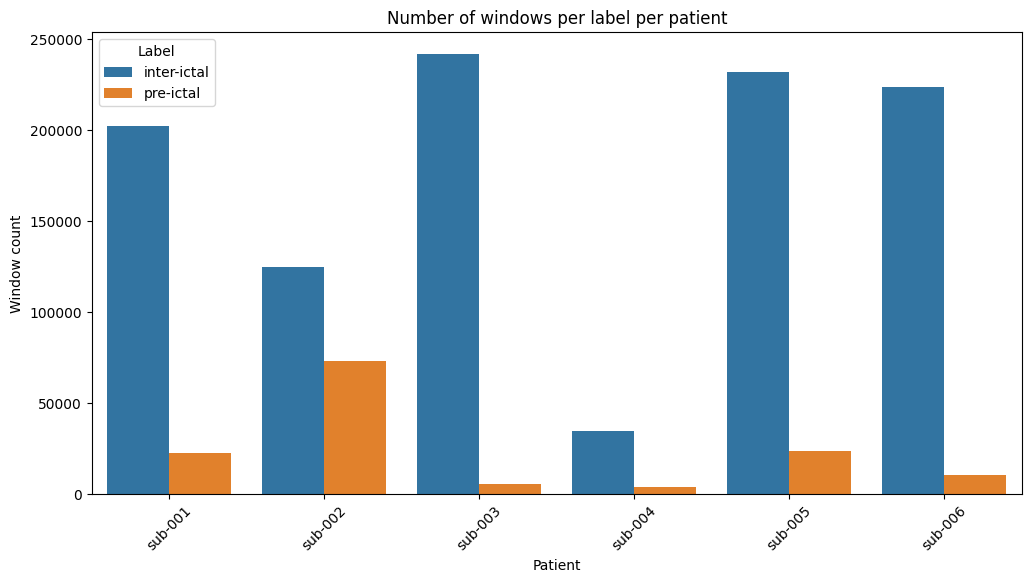

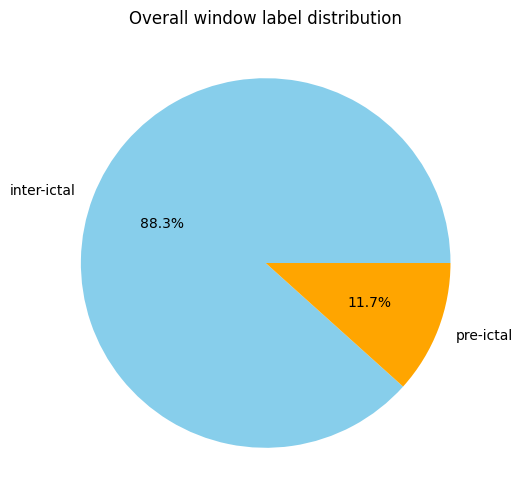

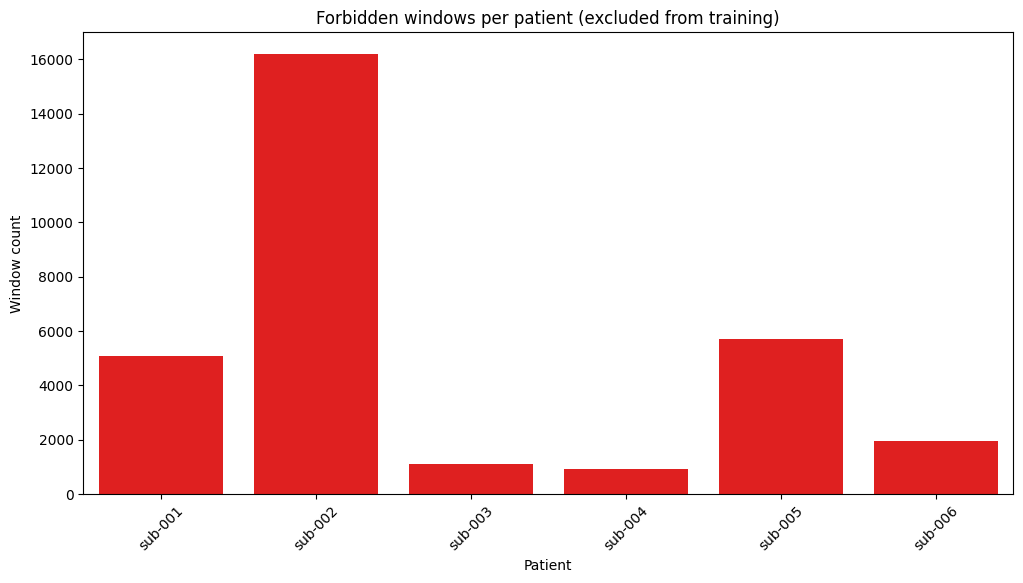

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load metadata CSV
meta_csv = "/kaggle/working/seizeit2_batch/preproc_windows/windows_metadata.csv"
df = pd.read_csv(meta_csv)

# === 1️⃣ عدد النوافذ لكل label ===
label_counts = df['label'].value_counts()
print("=== عدد النوافذ لكل label ===")
print(label_counts)

# === 2️⃣ عدد النوافذ لكل مريض حسب label (excluding forbidden) ===
train_df = df[df['label'] != 'forbidden']
patient_label_counts = train_df.groupby(['patient','label']).size().unstack(fill_value=0)
print("\n=== عدد النوافذ لكل مريض حسب label ===")
print(patient_label_counts)

# === 3️⃣ Imbalance ratio ===
total_inter = label_counts.get('inter-ictal', 0)
total_pre = label_counts.get('pre-ictal', 0)
ratio = total_inter / total_pre if total_pre > 0 else float('inf')
print(f"\nImbalance ratio (inter-ictal : pre-ictal) = 1:{ratio:.2f}")

# === 4️⃣ Visualization ===
plt.figure(figsize=(12,6))
sns.countplot(data=train_df, x='patient', hue='label')
plt.title("Number of windows per label per patient")
plt.ylabel("Window count")
plt.xlabel("Patient")
plt.legend(title="Label")
plt.xticks(rotation=45)
plt.show()

# Pie chart: نسبة imbalance العام
plt.figure(figsize=(6,6))
counts = train_df['label'].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=['skyblue','orange'])
plt.title("Overall window label distribution")
plt.show()

# Forbidden windows per patient
forbidden_df = df[df['label'] == 'forbidden']
plt.figure(figsize=(12,6))
sns.countplot(data=forbidden_df, x='patient', color='red')
plt.title("Forbidden windows per patient (excluded from training)")
plt.ylabel("Window count")
plt.xlabel("Patient")
plt.xticks(rotation=45)
plt.show()


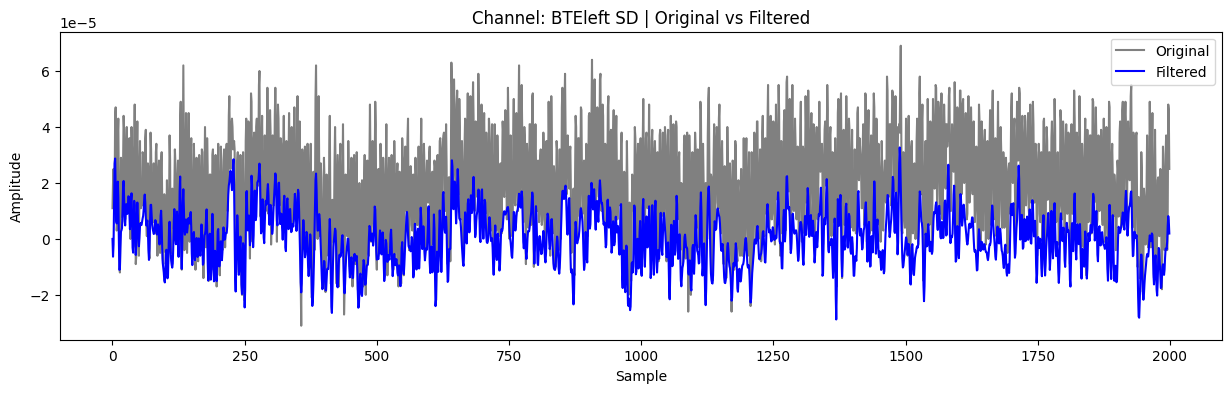

In [6]:
import mne
import matplotlib.pyplot as plt

# اختاري ملف EDF من المرضى الستة
edf_path = "/kaggle/working/seizeit2_batch/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf"

# 1️⃣ Load raw (preload=False بس عشان نقارن قبل الفلترة)
raw_orig = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
data_orig = raw_orig.get_data()
ch_name = raw_orig.ch_names[0]  # نختار أول قناة للمشاهدة

# 2️⃣ Apply same filters as in preprocessing (bandpass + notch)
raw_filt = raw_orig.copy()
ch_idx = 0
# فلترة EEG/ECG example
raw_filt._data[ch_idx, :] = mne.filter.filter_data(raw_filt._data[ch_idx, :], sfreq=raw_filt.info['sfreq'],
                                                   l_freq=0.5, h_freq=45., verbose=False)
raw_filt._data[ch_idx, :] = mne.filter.notch_filter(raw_filt._data[ch_idx, :], Fs=raw_filt.info['sfreq'],
                                                    freqs=[50.], verbose=False)
data_filt = raw_filt.get_data()[ch_idx]

# 3️⃣ Plot before/after
plt.figure(figsize=(15,4))
plt.plot(data_orig[ch_idx][:2000], color='gray', label='Original')  # أول 2000 عينة
plt.plot(data_filt[:2000], color='blue', label='Filtered')
plt.title(f"Channel: {ch_name} | Original vs Filtered")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


In [8]:
import numpy as np
import pandas as pd
import mne
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import joblib
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

In [9]:
# ========================================
# Load metadata
# ========================================
meta_path = "/kaggle/working/seizeit2_batch/preproc_windows/windows_metadata.csv"
df = pd.read_csv(meta_path)

# Physiological channels only (EEG + ECG + EMG)
TARGET_CHANNELS = ['BTEleft SD', 'CROSStop SD', 'ECG SD', 'EMG SD']
# اختار أول 6 مرضى للباتش الأول
train_patients = [f"sub-00{i}" for i in range(1,7)]
df_train = df[df["patient"].isin(train_patients)]

# 10% validation
val_fraction = 0.1
val_df = df_train.sample(frac=val_fraction, random_state=42)
train_df = df_train.drop(val_df.index)
print("Computing global scaler on training data...")

# اختياري: خذ عينة كبيرة لتوفير RAM أو كل train_df
sample_df = train_df.sample(n=min(10000, len(train_df)), random_state=42)

all_channels_data = []

for idx, row in sample_df.iterrows():
    raw = mne.io.read_raw_edf(row['edf_file'], preload=True, verbose='ERROR')
    sr = row['sr']
    start = int(row['window_start_s'] * sr)
    expected = int(10 * sr)
    
    data = np.zeros((4, expected), dtype='float32')
    for c, name in enumerate(TARGET_CHANNELS):
        if name in raw.ch_names:
            sig = raw.get_data(picks=name, start=start, stop=start+expected)
            data[c, :sig.shape[1]] = sig[0, :sig.shape[1]]
    
    all_channels_data.append(data)
    del raw
    gc.collect()

# جمع كل البيانات في array كبير
all_data = np.concatenate(all_channels_data, axis=1)  # shape (4, total_samples)
print("Total samples for scaling:", all_data.shape[1])

# حساب الـ scaler
global_scaler = StandardScaler()
global_scaler.fit(all_data.T)  # fit on (time_points, channels)

# حفظ الـ scaler
joblib.dump(global_scaler, '/kaggle/working/global_scaler.pkl')
print("Global scaler saved.")

Computing global scaler on training data...
Total samples for scaling: 25600000
Global scaler saved.


In [ ]:
# class SeizureWindowLoader(tf.keras.utils.Sequence):
#     def __init__(self, df, batch_size=32, augment=True, global_scaler=None, class_weights=None, seed=42):
#         self.df = df[df['label'] != 'forbidden'].copy()
#         self.df['label_num'] = self.df['label'].map({'inter-ictal':0, 'pre-ictal':1})
#         self.batch_size = batch_size
#         self.augment = augment
#         self.global_scaler = global_scaler
#         np.random.seed(seed)

#         # Class weights
#         if class_weights is None:
#             cw = compute_class_weight("balanced", classes=[0,1], y=self.df['label_num'])
#             self.class_weights = {0: float(cw[0]), 1: float(cw[1])}
#         else:
#             self.class_weights = class_weights

#         # Separate indices
#         self.pos_idx = self.df[self.df['label_num']==1].index.to_numpy()
#         self.neg_idx = self.df[self.df['label_num']==0].index.to_numpy()

#         # Make sure both lists are same length WITHOUT oversampling
#         min_len = min(len(self.pos_idx), len(self.neg_idx))
#         self.pos_idx = self.pos_idx[:min_len]
#         self.neg_idx = self.neg_idx[:min_len]

#         self.on_epoch_end()
    
#     def __len__(self):
#         return len(self.pos_idx) // (self.batch_size//2)
    
#     def on_epoch_end(self):
#         np.random.shuffle(self.pos_idx)
#         np.random.shuffle(self.neg_idx)

#     def augment_window(self, data):
#         data = data + np.random.normal(0, 0.05, data.shape).astype('float32')  # زيادة الضوضاء
#         data = np.roll(data, np.random.randint(-50,51), axis=1)
#         data *= np.random.uniform(0.9,1.1)
#         return data

#     def __getitem__(self, idx):
#         start_p = idx * (self.batch_size//2)
#         end_p = start_p + (self.batch_size//2)

#         pos_batch = self.pos_idx[start_p:end_p]
#         neg_batch = self.neg_idx[start_p:end_p]
#         batch_idx = np.concatenate([pos_batch, neg_batch])
#         np.random.shuffle(batch_idx)

#         X, y = [], []
#         for i in batch_idx:
#             row = self.df.loc[i]
#             raw = mne.io.read_raw_edf(row['edf_file'], preload=True, verbose='ERROR')
#             sr = row['sr']
#             start = int(row['window_start_s']*sr)
#             expected = int(10*sr)

#             data = np.zeros((4, expected), dtype='float32')
#             for c, name in enumerate(TARGET_CHANNELS):
#                 if name in raw.ch_names:
#                     sig = raw.get_data(picks=name, start=start, stop=start+expected)
#                     data[c, :sig.shape[1]] = sig[0, :sig.shape[1]]

#             # Normalize with global scaler
#             data = self.global_scaler.transform(data.T).T.astype('float32')

#             if self.augment and row['label_num']==1:
#                 data = self.augment_window(data)

#             # Transpose to (time, channels)
#             data = data.T
#             X.append(data)
#             y.append(row['label_num'])

#             del raw
#             gc.collect()

#         return np.array(X), np.array(y)

In [10]:
class SeizureWindowLoader(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, augment=True, global_scaler=None, class_weights=None, seed=42):
        # خليه dataset طبيعي
        self.df = df[df['label'] != 'forbidden'].copy()
        self.df['label_num'] = self.df['label'].map({'inter-ictal':0, 'pre-ictal':1})
        
        self.batch_size = batch_size
        self.augment = augment
        self.global_scaler = global_scaler
        np.random.seed(seed)

        # Class weights (هيستخدموا في model.fit)
        if class_weights is None:
            cw = compute_class_weight("balanced", classes=[0,1], y=self.df['label_num'])
            self.class_weights = {0: float(cw[0]), 1: float(cw[1])}
        else:
            self.class_weights = class_weights

        # Shuffle indices for randomness
        self.indices = self.df.index.to_numpy()
        self.on_epoch_end()
    
    def __len__(self):
        # عدد الباتشات بالكامل
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def on_epoch_end(self):
        # Shuffle data at epoch end
        np.random.shuffle(self.indices)

    def augment_window(self, data):
        # زي ما كان لكن ممكن نقلل الضوضاء شوية لو حبيتي
        data = data + np.random.normal(0, 0.02, data.shape).astype('float32')  # تشويش خفيف
        data = np.roll(data, np.random.randint(-50,51), axis=1)
        data *= np.random.uniform(0.9,1.1)
        return data

    def __getitem__(self, idx):
        # اختار batch عادي من dataset الطبيعي
        start = idx * self.batch_size
        end = start + self.batch_size
        batch_idx = self.indices[start:end]

        X, y = [], []
        for i in batch_idx:
            row = self.df.loc[i]
            raw = mne.io.read_raw_edf(row['edf_file'], preload=True, verbose='ERROR')
            sr = row['sr']
            start_s = int(row['window_start_s'] * sr)
            expected = int(10 * sr)

            data = np.zeros((4, expected), dtype='float32')
            for c, name in enumerate(TARGET_CHANNELS):
                if name in raw.ch_names:
                    sig = raw.get_data(picks=name, start=start_s, stop=start_s+expected)
                    data[c, :sig.shape[1]] = sig[0, :sig.shape[1]]

            # Normalize with global scaler
            data = self.global_scaler.transform(data.T).T.astype('float32')

            # Augmentation فقط للـ pre-ictal
            if self.augment and row['label_num'] == 1:
                data = self.augment_window(data)

            X.append(data.T)  # (time, channels)
            y.append(row['label_num'])

            del raw
            gc.collect()

        return np.array(X), np.array(y)


In [11]:
# Load global scaler
global_scaler = joblib.load('/kaggle/working/global_scaler.pkl')

train_loader = SeizureWindowLoader(train_df, batch_size=16, augment=True, global_scaler=global_scaler)
val_loader = SeizureWindowLoader(val_df, batch_size=16, augment=False, global_scaler=global_scaler, class_weights=train_loader.class_weights)

print("Train loader:", len(train_loader), "batches")
print("Validation loader:", len(val_loader), "batches")

Train loader: 67489 batches
Validation loader: 7499 batches


# Build CNN 1D Model

In [12]:
def build_cnn_1d(input_shape=(2560,4)):
    model = models.Sequential([
        layers.Conv1D(96, kernel_size=61, padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(4),

        layers.Conv1D(192, kernel_size=31, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(4),

        layers.Conv1D(384, kernel_size=15, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(4),

        layers.Conv1D(512, kernel_size=7, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ], name="CNN_1D_EEG_ECG_EMG")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), 'Precision', 'Recall']
    )
    return model

model = build_cnn_1d(input_shape=(2560,4))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-16 23:56:52.004564: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "CNN_1D_EEG_ECG_EMG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2560, 96)       │        23,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2560, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 2560, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 640, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 640, 192)       │       571,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 640, 192)       │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 640, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 160, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 160, 384)       │     1,106,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 160, 384)       │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 160, 384)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 40, 384)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 40, 512)        │     1,376,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 40, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,346,081 (12.76 MB)

 Trainable params: 3,343,713 (12.76 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [ ]:
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath="/kaggle/working/batch1_best.keras",
        monitor='val_auc',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath="/kaggle/working/batch1_epoch_{epoch:02d}.keras",
        save_best_only=False,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=30,
    class_weight=train_loader.class_weights,
    callbacks=callbacks_list,
    verbose=1
)

# Save model + history
model.save("/kaggle/working/batch1_final.keras")
print("Training completed or stopped.")
print("Last epoch reached:", len(history.history['auc']))
print("Best val AUC:", max(history.history['val_auc']))

import pickle
with open('/kaggle/working/batch1_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("History saved for resume!")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
   93/67489 ━━━━━━━━━━━━━━━━━━━━ 416:40:41 22s/step - Precision: 0.1285 - Recall: 0.3484 - accuracy: 0.6745 - auc: 0.5201 - loss: 0.7675